In [48]:
pip install -U keras-tuner

In [49]:
import numpy as np
import pandas as pd
import tensorflow as tf
import kerastuner as kt
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Dropout

In [50]:
df = pd.read_csv('/content/diabetes.csv')

In [51]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [52]:
df.corr()['Outcome']

,Outcome
Pregnancies,0.221898
Glucose,0.466581
BloodPressure,0.065068
SkinThickness,0.074752
Insulin,0.130548
BMI,0.292695
DiabetesPedigreeFunction,0.173844
Age,0.238356
Outcome,1.000000


In [53]:
x = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [54]:
scaler = StandardScaler()

In [55]:
X = scaler.fit_transform(x)

In [56]:
X.shape

(768, 8)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [58]:
def plot_training_history(history_object):
    plt.figure(figsize=(10, 6))
    plt.plot(history_object.history['accuracy'])
    plt.plot(history_object.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(history_object.history['loss'])
    plt.plot(history_object.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

In [59]:
model = Sequential()
model.add(Dense(32, activation='relu', input_dim=8))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
h = model.fit(X_train, y_train, batch_size=32, epochs=100, validation_data=(X_test, y_test))

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4625 - loss: 0.7343 - val_accuracy: 0.5584 - val_loss: 0.7087
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6319 - loss: 0.6675 - val_accuracy: 0.6688 - val_loss: 0.6533
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6824 - loss: 0.6219 - val_accuracy: 0.7403 - val_loss: 0.6126
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7215 - loss: 0.5885 - val_accuracy: 0.7597 - val_loss: 0.5824
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7329 - loss: 0.5642 - val_accuracy: 0.7532 - val_loss: 0.5597
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7443 - loss: 0.5444 - val_accuracy: 0.7662 - val_loss: 0.5412
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7459 - loss: 0.5299 - val_accuracy: 0.7857 - val_loss: 0.5272
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7590 - loss: 0.5184 - val_accuracy: 0.772

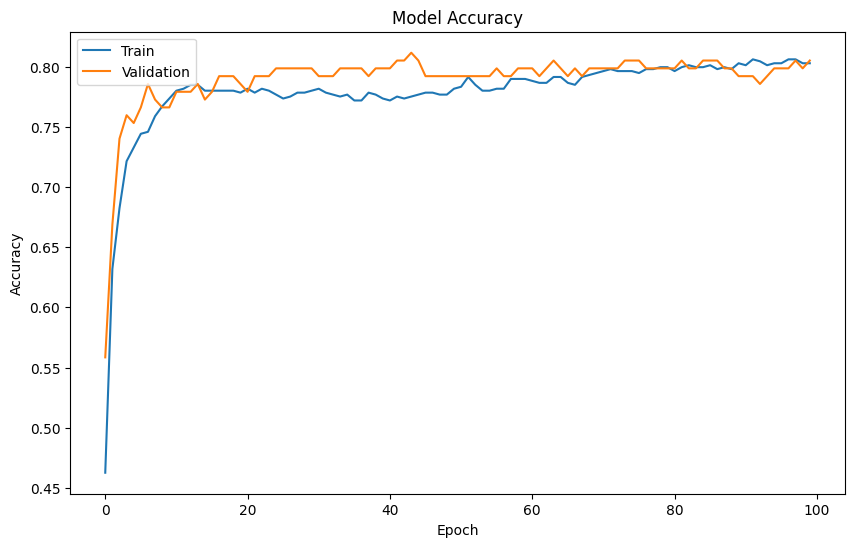

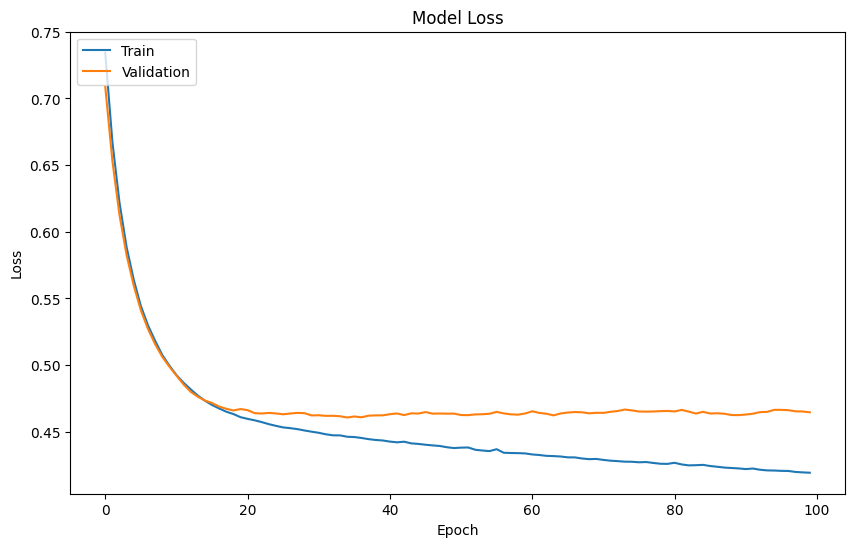

In [61]:
plot_training_history(h)

**Optimizers Using Keras Tuner**

In [62]:
def build_model(hp):
  model = Sequential()
  model.add(Dense(32, activation='relu', input_dim=8))
  model.add(Dense(1, activation='sigmoid'))
  optimizer = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop', 'adadelta'])
  model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
  return model

In [63]:
tuner = kt.RandomSearch(build_model, objective='val_accuracy', max_trials=5)

Reloading Tuner from ./untitled_project/tuner0.json


In [64]:
tuner.search(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

In [65]:
tuner.results_summary()

Results summary
Results in ./untitled_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0 summary
Hyperparameters:
optimizer: rmsprop
Score: 0.7662337422370911

Trial 2 summary
Hyperparameters:
optimizer: adam
Score: 0.7532467246055603

Trial 3 summary
Hyperparameters:
optimizer: sgd
Score: 0.7272727489471436

Trial 1 summary
Hyperparameters:
optimizer: adadelta
Score: 0.5259740352630615


In [66]:
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'rmsprop'}

In [67]:
model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [68]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

initial_epoch means we start from later epoch as some already train during tuner

In [69]:
a = model.fit(X_train, y_train, batch_size=32, epochs=100, initial_epoch=5, validation_data=(X_test, y_test))

Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7362 - loss: 0.5442 - val_accuracy: 0.7532 - val_loss: 0.5198
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7443 - loss: 0.5236 - val_accuracy: 0.7597 - val_loss: 0.5082
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7557 - loss: 0.5093 - val_accuracy: 0.7597 - val_loss: 0.5004
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7606 - loss: 0.4995 - val_accuracy: 0.7662 - val_loss: 0.4949
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7671 - loss: 0.4915 - val_accuracy: 0.7662 - val_loss: 0.4916
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7752 - loss: 0.4852 - val_accuracy: 0.7727 - val_loss: 0.4892
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7720 - loss: 0.4801 - val_accuracy: 0.7857 - val_loss: 0.4868
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7785 - loss: 0.4764 - val_accuracy

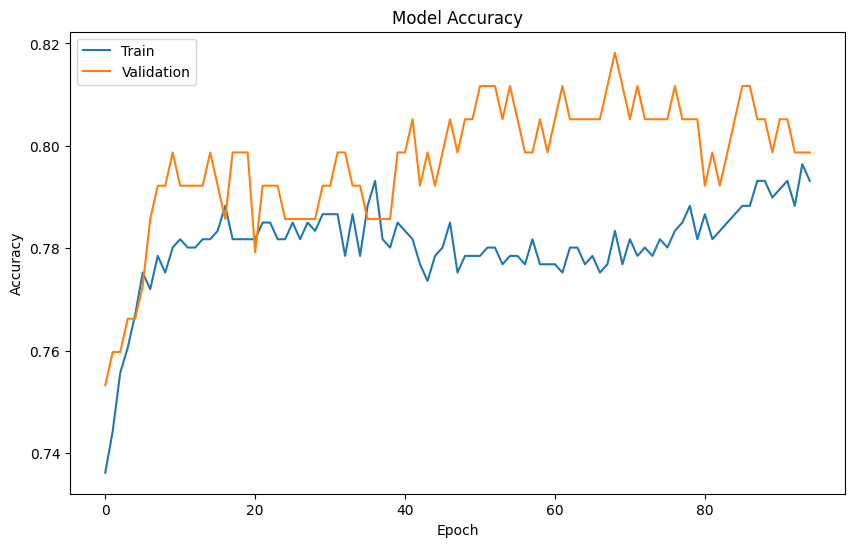

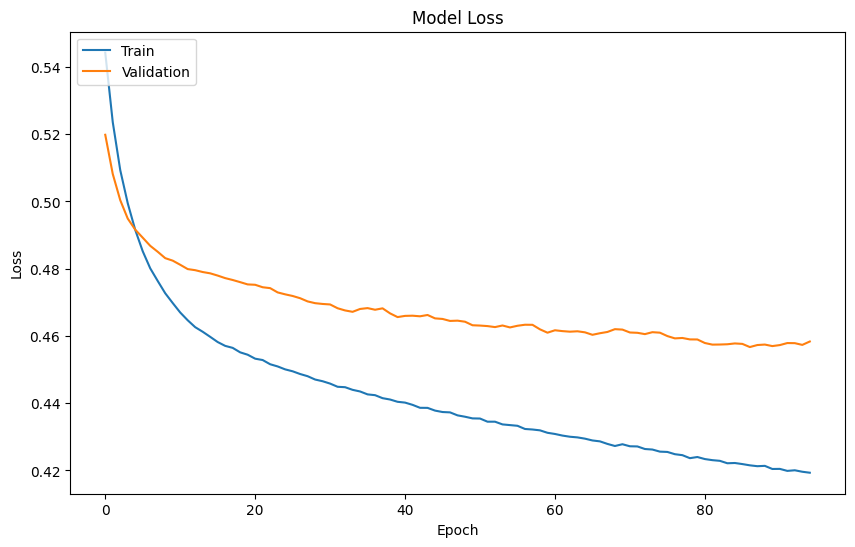

In [70]:
plot_training_history(a)

**No. of Neurons using Keras Tuner**

In [71]:
def build_model(hp):
  model = Sequential()
  units = hp.Int('units', min_value=8, max_value=128, step=8)
  model.add(Dense(units=units, activation='relu', input_dim=8))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
  return model

In [72]:
tuner = kt.RandomSearch(build_model, objective='val_accuracy', max_trials=5, directory='my_dirr', project_name='neuron_tuning_project')

Reloading Tuner from my_dirr/neuron_tuning_project/tuner0.json


In [73]:
tuner.search(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

In [74]:
tuner.results_summary()

Results summary
Results in my_dirr/neuron_tuning_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 2 summary
Hyperparameters:
units: 120
Score: 0.798701286315918

Trial 3 summary
Hyperparameters:
units: 64
Score: 0.798701286315918

Trial 4 summary
Hyperparameters:
units: 56
Score: 0.7792207598686218

Trial 0 summary
Hyperparameters:
units: 16
Score: 0.7467532753944397

Trial 1 summary
Hyperparameters:
units: 32
Score: 0.7272727489471436


In [75]:
tuner.get_best_hyperparameters()[0].values

{'units': 120}

In [76]:
model=tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [77]:
b = model.fit(X_train, y_train, batch_size=32, epochs=100, initial_epoch=5,  validation_data=(X_test, y_test))

Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7720 - loss: 0.4975 - val_accuracy: 0.7922 - val_loss: 0.4744
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7785 - loss: 0.4784 - val_accuracy: 0.7987 - val_loss: 0.4671
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7834 - loss: 0.4685 - val_accuracy: 0.7987 - val_loss: 0.4610
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7866 - loss: 0.4626 - val_accuracy: 0.7922 - val_loss: 0.4588
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7785 - loss: 0.4571 - val_accuracy: 0.7857 - val_loss: 0.4555
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7850 - loss: 0.4550 - val_accuracy: 0.7727 - val_loss: 0.4564
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7866 - loss: 0.4518 - val_accuracy: 0.7727 - val_loss: 0.4545
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7720 - loss: 0.4507 - val_accuracy: 0.798

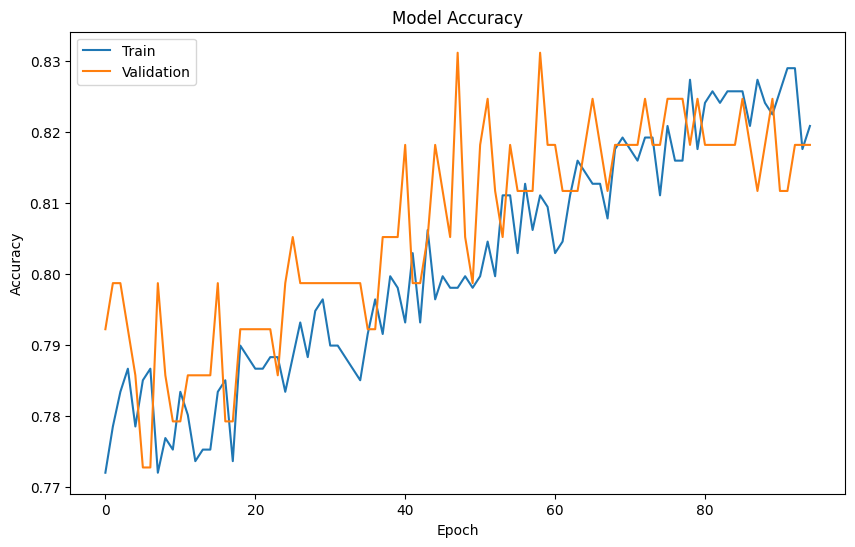

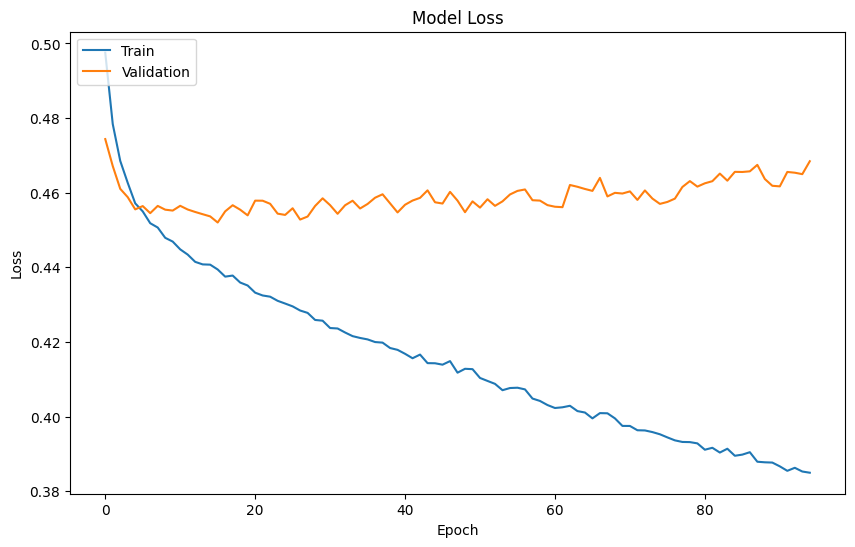

In [78]:
plot_training_history(b)

**No. of Layers using Keras Tuner**

In [79]:
def build_model(hp):
  model=Sequential()
  model.add(Dense(56, ))
  for i in range(hp.Int('num_layers', min_value=1, max_value=10)):
    model.add(Dense(56, activation='relu'))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
  return model

In [80]:
tuner = kt.RandomSearch(build_model, objective='val_accuracy', max_trials=3, directory='my_dirr', project_name='layers_tuning_project')

Reloading Tuner from my_dirr/layers_tuning_project/tuner0.json


In [81]:
tuner.search(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

In [82]:
tuner.results_summary()

Results summary
Results in my_dirr/layers_tuning_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 1 summary
Hyperparameters:
num_layers: 2
Score: 0.8051947951316833

Trial 2 summary
Hyperparameters:
num_layers: 3
Score: 0.798701286315918

Trial 0 summary
Hyperparameters:
num_layers: 1
Score: 0.798701286315918


In [83]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 2}

In [84]:
model=tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [85]:
c = model.fit(X_train, y_train, batch_size=32, epochs=100, initial_epoch=5,  validation_data=(X_test, y_test))

Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7818 - loss: 0.4453 - val_accuracy: 0.7922 - val_loss: 0.4789
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7915 - loss: 0.4307 - val_accuracy: 0.7987 - val_loss: 0.4778
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7883 - loss: 0.4247 - val_accuracy: 0.8052 - val_loss: 0.4693
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8029 - loss: 0.4207 - val_accuracy: 0.7987 - val_loss: 0.4611
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8046 - loss: 0.4194 - val_accuracy: 0.7857 - val_loss: 0.4693
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7997 - loss: 0.4151 - val_accuracy: 0.7922 - val_loss: 0.4678
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8127 - loss: 0.4106 - val_accuracy: 0.7922 - val_loss: 0.4671
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7997 - loss: 0.4104 - val_accuracy: 0.798

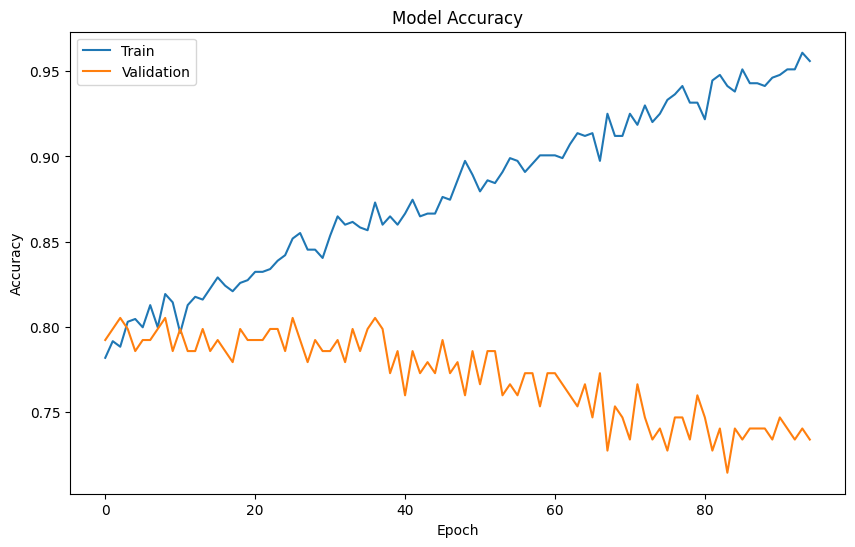

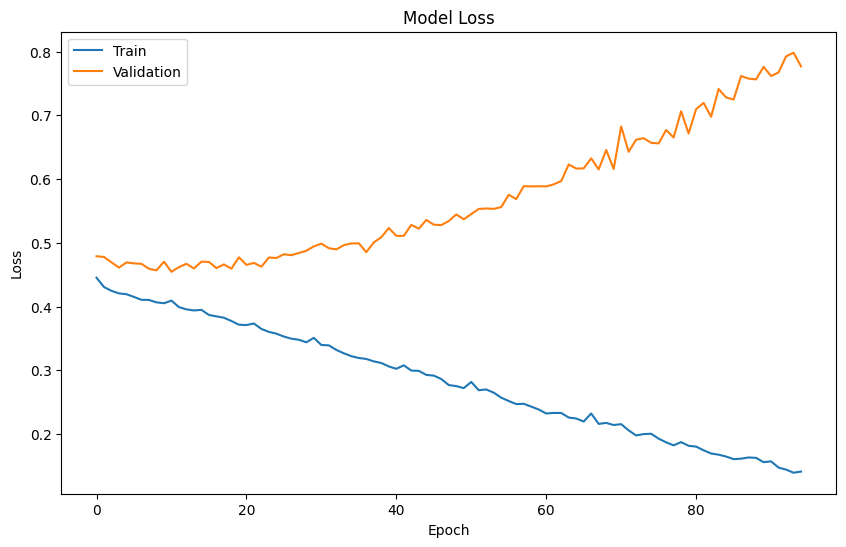

In [86]:
plot_training_history(c)

**Multiple hyperparametes at once using Kears Tuner**

In [87]:
def build_model(hp):
  model = Sequential()
  num_layers = hp.Int('num_layers', min_value=1, max_value=10)
  for i in range(num_layers):
    if i == 0:
      model.add(
          Dense(
              hp.Int('units_' + str(i), min_value=8, max_value=128, step=8),
              activation=hp.Choice('activation_' + str(i), values=['relu', 'tanh', 'sigmoid']),
              input_dim=8
              )
          )
      model.add(Dropout(hp.Choice('dropout_' + str(i), values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
    else:
      model.add(
          Dense(
              hp.Int('units_' + str(i), min_value=8, max_value=128, step=8),
              activation=hp.Choice('activation_' + str(i), values=['relu', 'tanh', 'sigmoid'])
              )
          )
      model.add(Dropout(hp.Choice('dropout_' + str(i), values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(optimizer=hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop', 'adadelta']),
                loss='binary_crossentropy', metrics=['accuracy'])
  return model

In [88]:
tuner = kt.RandomSearch(build_model, objective='val_accuracy', max_trials=5, directory='my_dirr', project_name='models_tuning_project')

Reloading Tuner from my_dirr/models_tuning_project/tuner0.json


In [89]:
tuner.search(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

In [90]:
tuner.results_summary()

Results summary
Results in my_dirr/models_tuning_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 2 summary
Hyperparameters:
num_layers: 4
units_0: 112
activation_0: relu
dropout_0: 0.3
optimizer: sgd
units_1: 120
activation_1: sigmoid
dropout_1: 0.7
units_2: 80
activation_2: sigmoid
dropout_2: 0.1
units_3: 40
activation_3: relu
dropout_3: 0.1
units_4: 104
activation_4: sigmoid
dropout_4: 0.1
units_5: 96
activation_5: relu
dropout_5: 0.3
units_6: 16
activation_6: tanh
dropout_6: 0.9
Score: 0.6428571343421936

Trial 4 summary
Hyperparameters:
num_layers: 9
units_0: 40
activation_0: relu
dropout_0: 0.9
optimizer: adam
units_1: 8
activation_1: sigmoid
dropout_1: 0.8
units_2: 56
activation_2: tanh
dropout_2: 0.3
units_3: 64
activation_3: sigmoid
dropout_3: 0.5
units_4: 32
activation_4: tanh
dropout_4: 0.4
units_5: 112
activation_5: sigmoid
dropout_5: 0.4
units_6: 56
activation_6: relu
dropout_6: 0.9
units_7: 8
activation_7: relu
dropout_7: 0.1
units_8: 

In [91]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 4,
 'units_0': 112,
 'activation_0': 'relu',
 'dropout_0': 0.3,
 'optimizer': 'sgd',
 'units_1': 120,
 'activation_1': 'sigmoid',
 'dropout_1': 0.7,
 'units_2': 80,
 'activation_2': 'sigmoid',
 'dropout_2': 0.1,
 'units_3': 40,
 'activation_3': 'relu',
 'dropout_3': 0.1,
 'units_4': 104,
 'activation_4': 'sigmoid',
 'dropout_4': 0.1,
 'units_5': 96,
 'activation_5': 'relu',
 'dropout_5': 0.3,
 'units_6': 16,
 'activation_6': 'tanh',
 'dropout_6': 0.9}

In [92]:
model=tuner.get_best_models(num_models=1)[0]

In [93]:
d = model.fit(X_train, y_train, batch_size=32, epochs=100, initial_epoch=5,  validation_data=(X_test, y_test))

Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6368 - loss: 0.6524 - val_accuracy: 0.6429 - val_loss: 0.6516
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6531 - loss: 0.6510 - val_accuracy: 0.6429 - val_loss: 0.6500
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6547 - loss: 0.6544 - val_accuracy: 0.6429 - val_loss: 0.6503
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6498 - loss: 0.6523 - val_accuracy: 0.6429 - val_loss: 0.6498
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6515 - loss: 0.6533 - val_accuracy: 0.6429 - val_loss: 0.6499
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6531 - loss: 0.6451 - val_accuracy: 0.6429 - val_loss: 0.6499
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6531 - loss: 0.6442 - val_accuracy: 0.6429 - val_loss: 0.6499
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6450 - loss: 0.6523 - val_accuracy: 0.

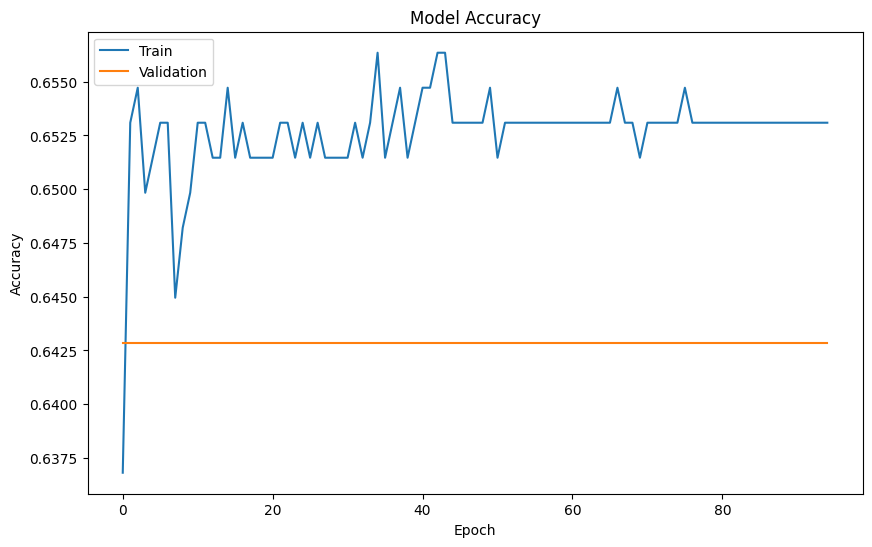

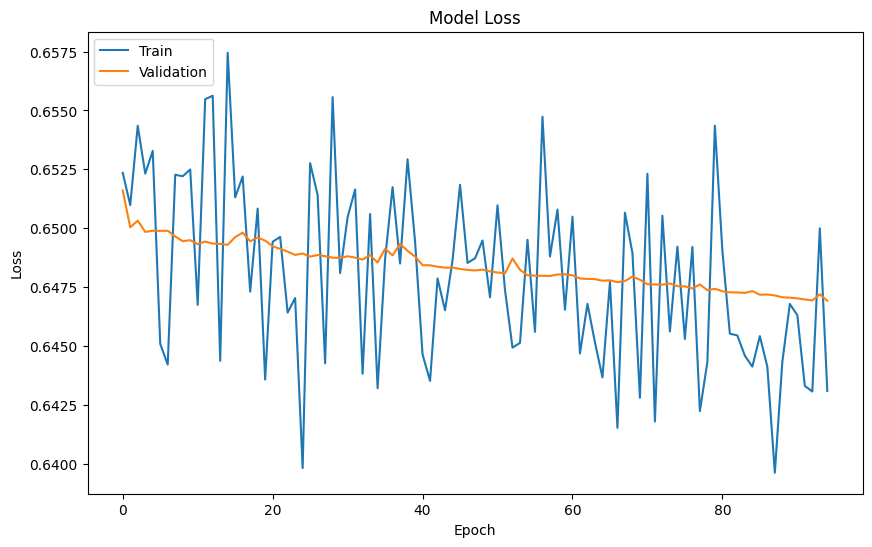

In [94]:
plot_training_history(d)